### **Required Dependencies**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

### **Data Loading and Understanding**

In [17]:
df = pd.read_csv('/content/train.csv')
df

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,0,1,0,0,0,0,0,0,1,1,16.597187,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,1,20.703001,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,0,5.711481,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,0,16.414305,f,?,no,no,Canada,no,9.069342,18 and more,Self,0


In [18]:
df.shape

(800, 22)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [20]:
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [21]:
pd.set_option('display.max_columns', None)

In [22]:
df['age'] = df['age'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    int64  
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [24]:
for col in df.columns:
  numerical_cols = ["ID", "age", "result"]
  if col not in numerical_cols:
    print(col, df[col].unique())
    print("-"*100)

A1_Score [1 0]
----------------------------------------------------------------------------------------------------
A2_Score [0 1]
----------------------------------------------------------------------------------------------------
A3_Score [1 0]
----------------------------------------------------------------------------------------------------
A4_Score [0 1]
----------------------------------------------------------------------------------------------------
A5_Score [1 0]
----------------------------------------------------------------------------------------------------
A6_Score [0 1]
----------------------------------------------------------------------------------------------------
A7_Score [1 0]
----------------------------------------------------------------------------------------------------
A8_Score [0 1]
----------------------------------------------------------------------------------------------------
A9_Score [1 0]
---------------------------------------------------------

In [25]:
df = df.drop(columns = ["ID", "age_desc"])

In [26]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [27]:
df['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [28]:
mapping = {
    'Viet Nam': 'Vietnam',
    'AmericanSamoa': 'United States',
    'Hong Kong': 'China'
}

df['contry_of_res'] = df['contry_of_res'].replace(mapping)

In [29]:
df['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

In [30]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


## Key Insights from Data Preprocessing & Exploratory Analysis

1. **Missing Values Detected**
   - Missing values were identified in the **`ethnicity`** and **`relation`** columns.
   - Appropriate handling techniques were applied to ensure data quality and consistency.

2. **Removal of Low-Variance Feature**
   - The **`age_desc`** column contained only a single unique value across all records.
   - Since it provided no discriminatory information for predictive modeling, it was removed from the dataset.

3. **Standardization of Country Names**
   - Inconsistencies and formatting issues in the **country** field were corrected.
   - Country names were standardized to improve data integrity and analytical accuracy.

4. **Target Variable Imbalance**
   - A noticeable **class imbalance** was observed in the target variable.
   - This was considered during model development to minimize bias and improve predictive performance.

## **Exploratory Data Analysis**

In [31]:
df.shape

(800, 20)

In [33]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [34]:
df.head(5)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,Self,0


In [35]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


### **Univariate Analysis**

**Numerical Columns**


*   Age
*   Result



In [37]:
sns.set_theme(style = "darkgrid")
sns.set_style(style = "whitegrid")

**Destribution Plots**

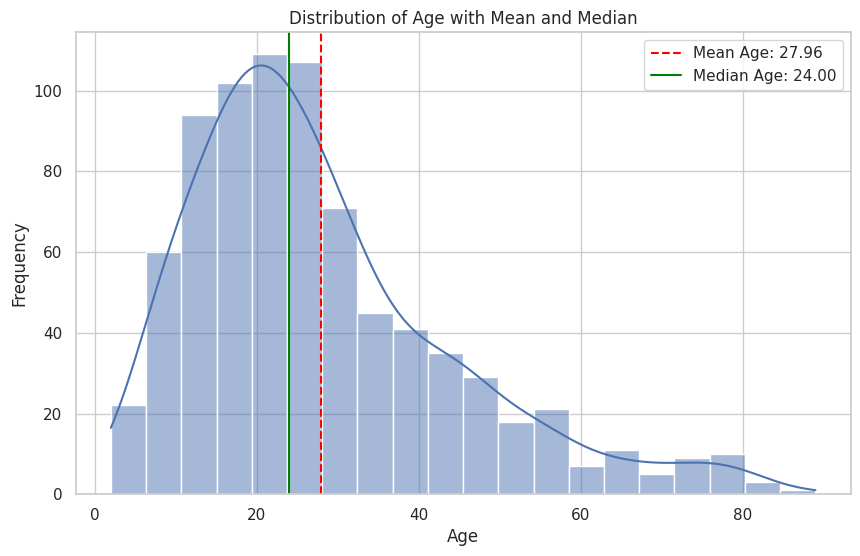

In [39]:
mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=20)
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Age: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='-', label=f'Median Age: {median_age:.2f}')
plt.title('Distribution of Age with Mean and Median')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

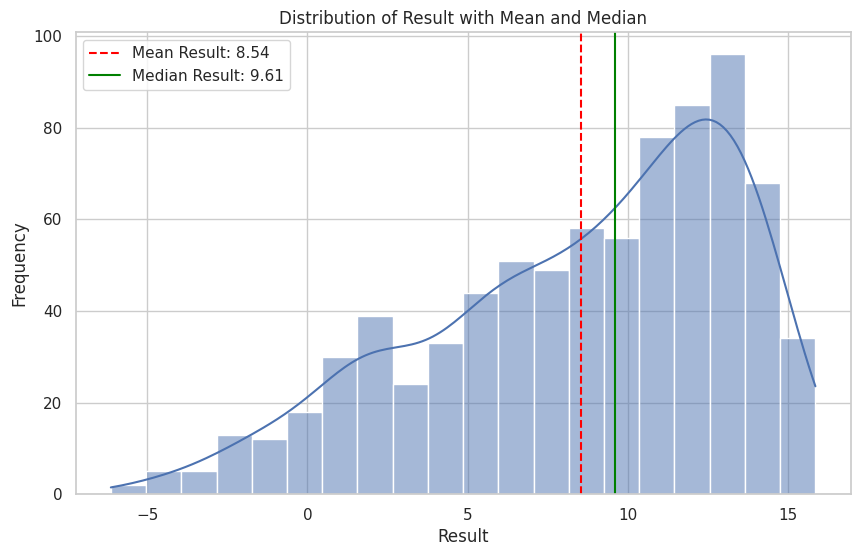

In [40]:
mean_age = df['result'].mean()
median_age = df['result'].median()

plt.figure(figsize=(10, 6))
sns.histplot(df['result'], kde=True, bins=20)
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Result: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='-', label=f'Median Result: {median_age:.2f}')
plt.title('Distribution of Result with Mean and Median')
plt.xlabel('Result')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Box plot fot the identification of outliers**

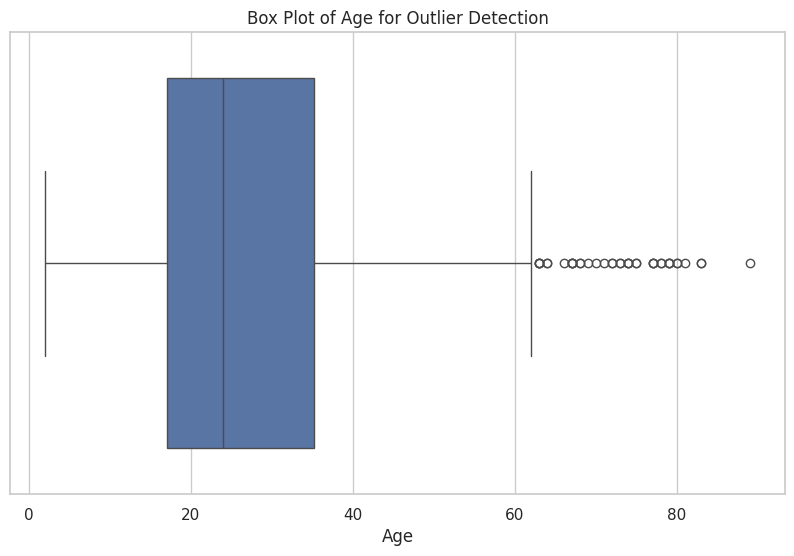

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['age'])
plt.title('Box Plot of Age for Outlier Detection')
plt.xlabel('Age')
plt.show()

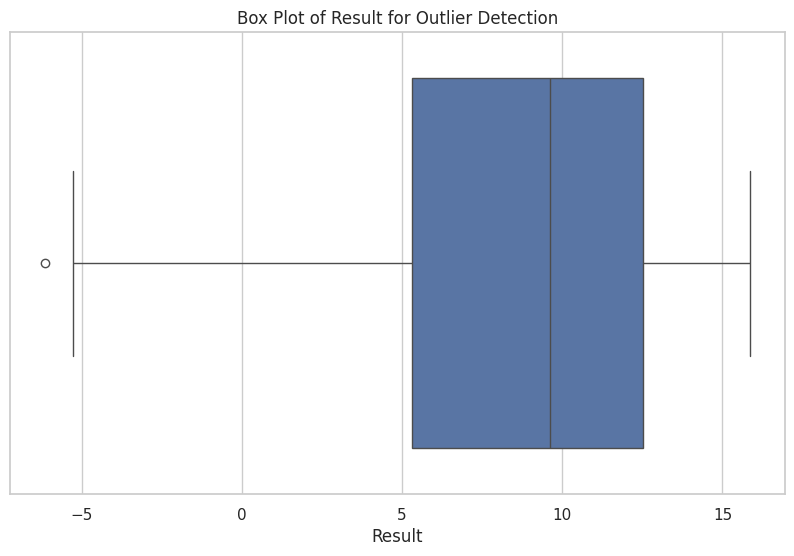

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['result'])
plt.title('Box Plot of Result for Outlier Detection')
plt.xlabel('Result')
plt.show()

In [43]:
numerical_columns = ['age', 'result']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)

    print(f"Column '{col}':")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {num_outliers}\n")

Column 'age':
  Q1: 17.00
  Q3: 35.25
  IQR: 18.25
  Lower Bound: -10.38
  Upper Bound: 62.62
  Number of outliers: 39

Column 'result':
  Q1: 5.31
  Q3: 12.51
  IQR: 7.21
  Lower Bound: -5.51
  Upper Bound: 23.33
  Number of outliers: 1



**Univariate Analysis on Categorical Columns**

In [44]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [45]:
categorical_columns = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before','relation']

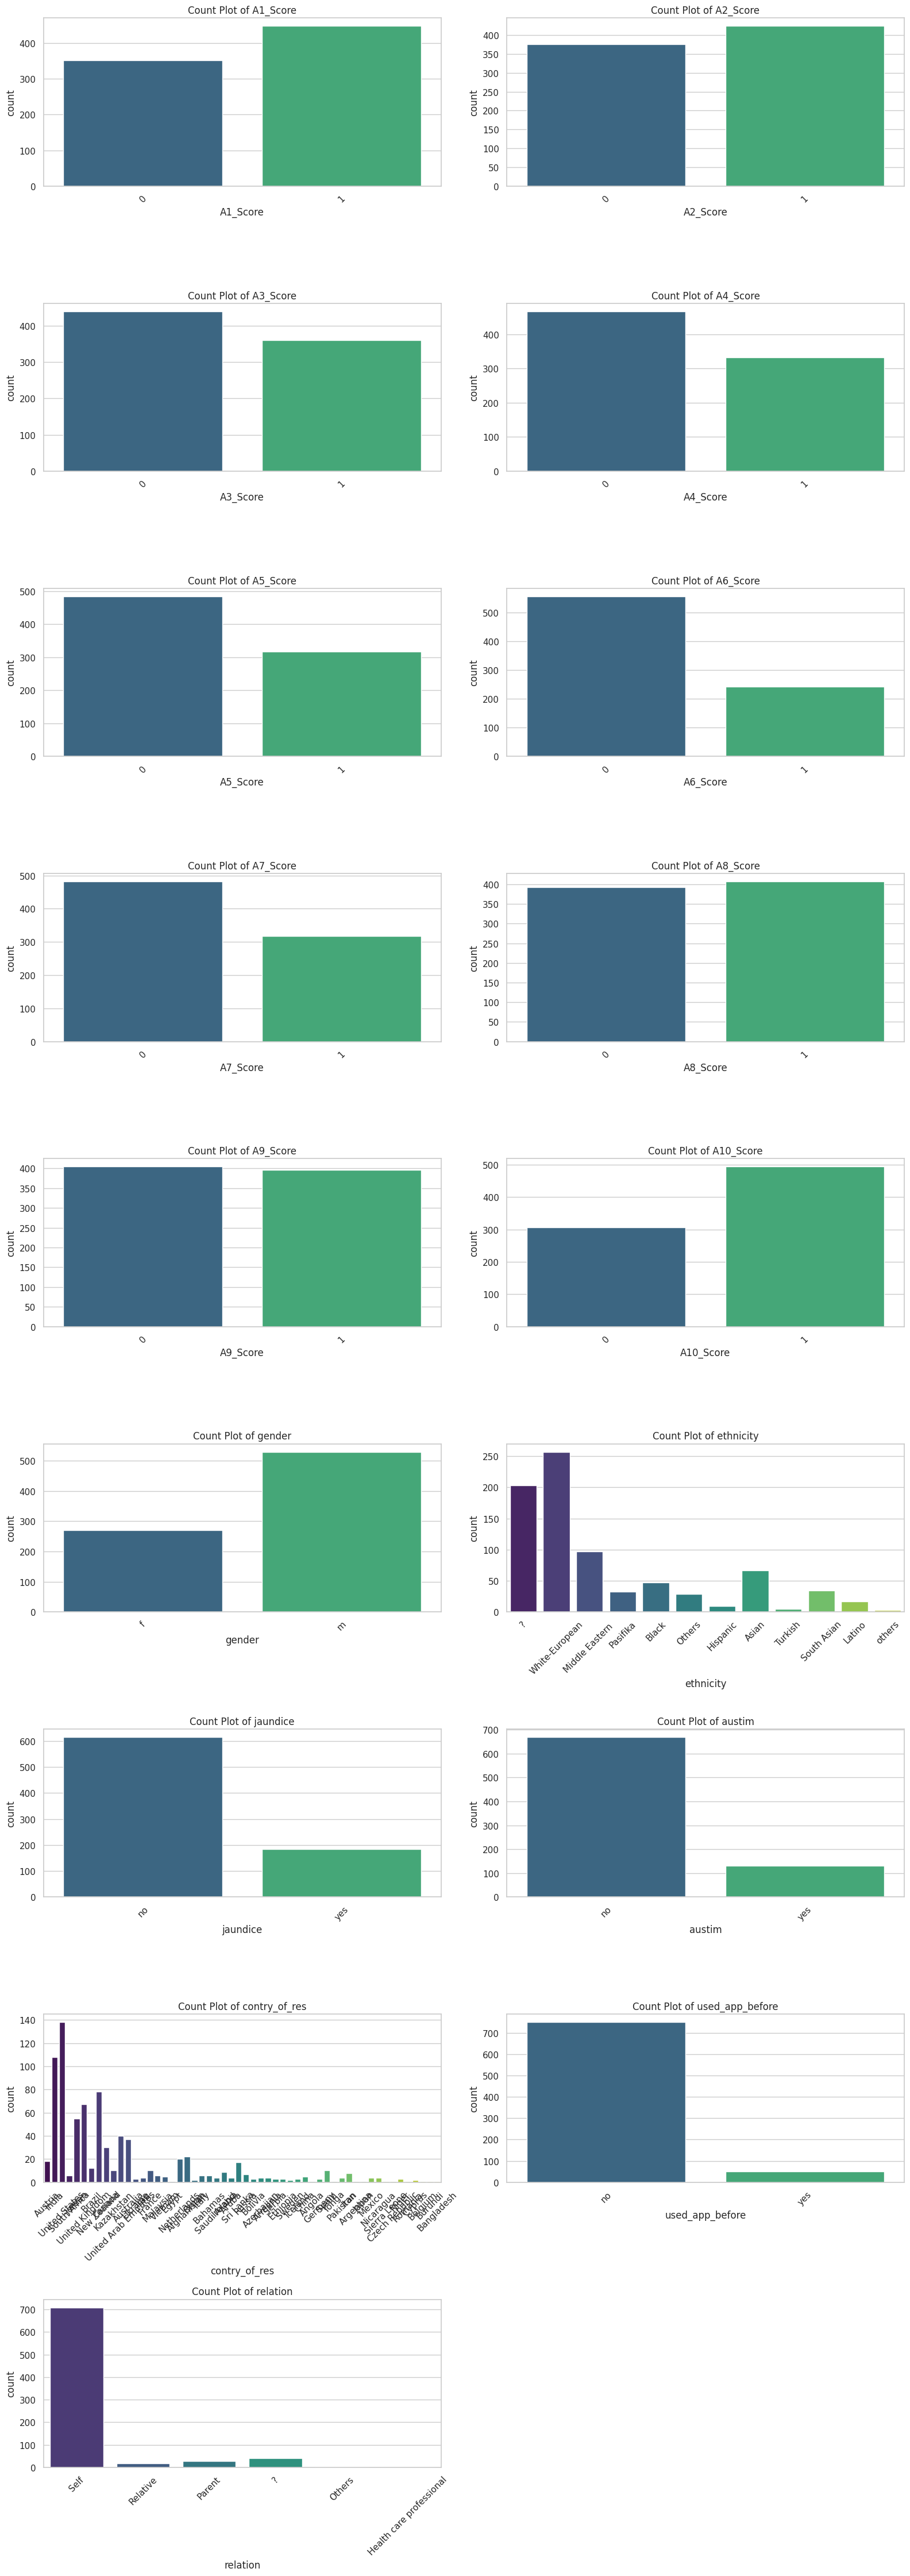

In [53]:
def plot_categorical_counts(df, columns):
    """Plots count plots for a list of categorical columns in a dataframe."""
    num_cols = len(columns)
    rows = (num_cols + 1) // 2

    plt.figure(figsize=(16, rows * 5))

    for i, col in enumerate(columns):
        plt.subplot(rows, 2, i + 1)
        sns.countplot(data=df, x=col, hue=col, palette="viridis", legend=False)
        plt.title(f'Count Plot of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()

    plt.show()

plot_categorical_counts(df, categorical_columns)

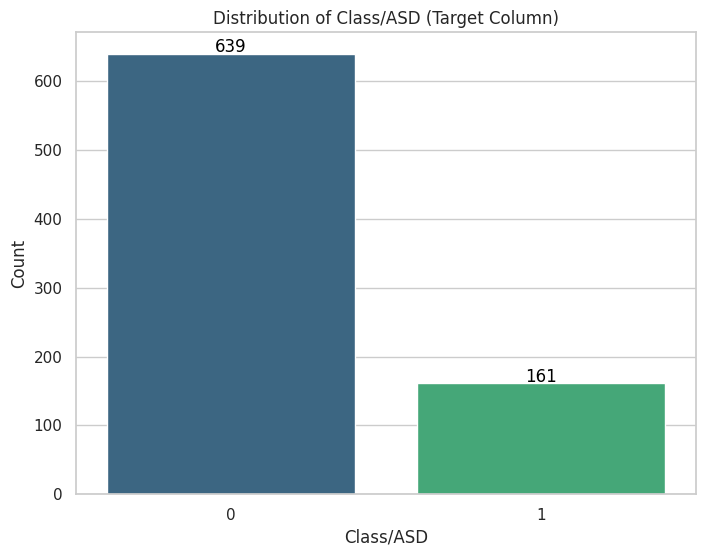

In [55]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Class/ASD', hue='Class/ASD', palette='viridis', legend=False)
plt.title('Distribution of Class/ASD (Target Column)')
plt.xlabel('Class/ASD')
plt.ylabel('Count')

# Adding count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

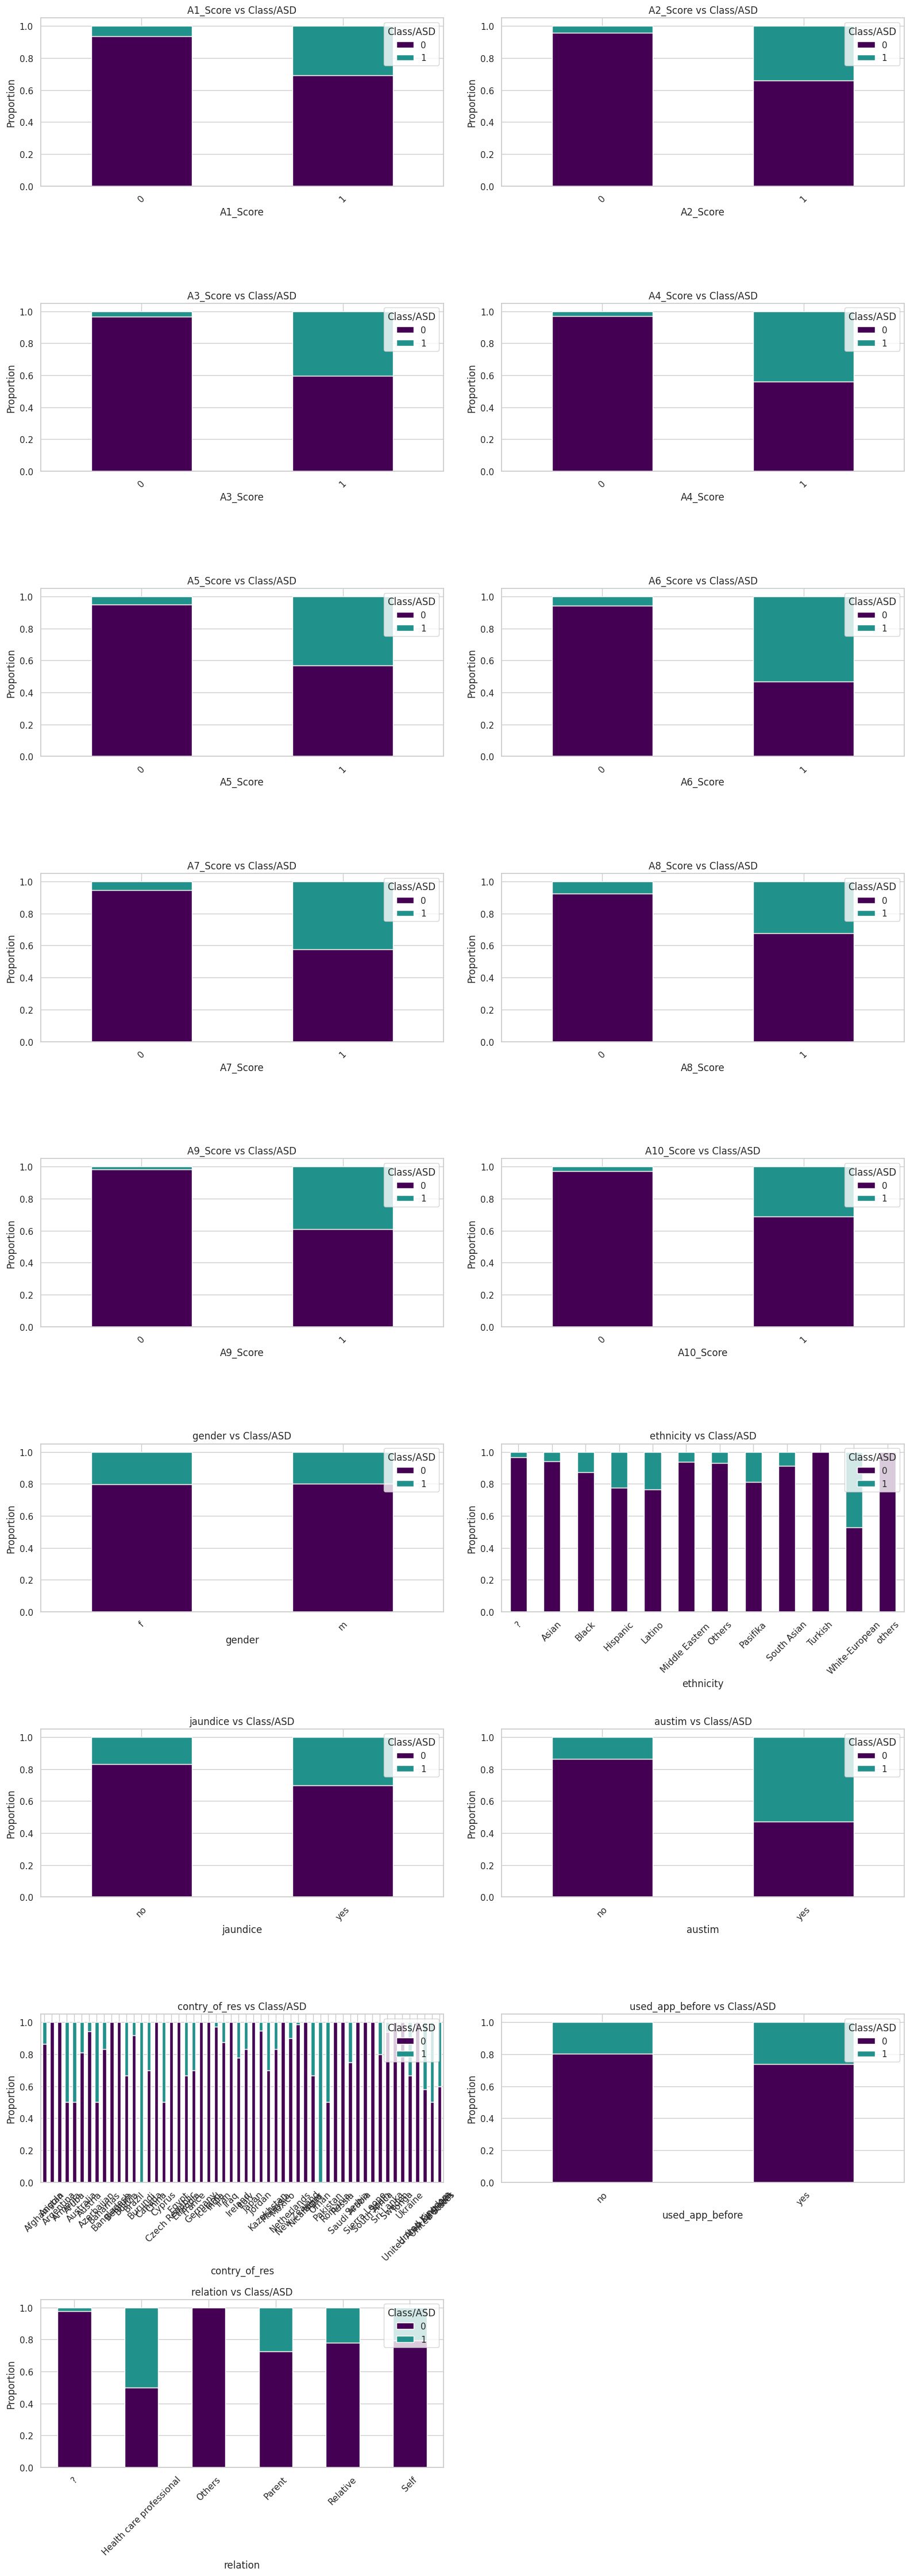

In [56]:
def plot_categorical_vs_target(df, columns, target):
    num_cols = len(columns)
    rows = (num_cols + 1) // 2
    plt.figure(figsize=(16, rows * 5))
    for i, col in enumerate(columns):
        plt.subplot(rows, 2, i + 1)
        ct = pd.crosstab(df[col], df[target], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#440154', '#21918c'])
        plt.title(f'{col} vs {target}')
        plt.ylabel('Proportion')
        plt.xticks(rotation=45)
        plt.legend(title=target, loc='upper right')
        plt.tight_layout()
    plt.show()

plot_categorical_vs_target(df, categorical_columns, 'Class/ASD')

**Handling missing values in ethnicity and relation column**

In [60]:
df['ethnicity'] = df['ethnicity'].replace({'?': 'Others', 'others': 'Others'})

In [61]:
df['ethnicity'].unique()

array(['Others', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [58]:
df['relation'].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [62]:
df['relation'] = df['relation'].replace({
    'Relative': 'Others',
    'Parent': 'Others',
    '?': 'Others',
    'Health care professional': 'Others'
})

In [63]:
df['relation'].unique()

array(['Self', 'Others'], dtype=object)

**Label Encoding**

In [64]:
object_columns = df.select_dtypes(include=['object']).columns

In [65]:
print(object_columns)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')


In [66]:
encoders = {}

for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

with open('label_encoders.pkl', 'wb') as file:
  pickle.dump(encoders, file)

In [67]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

In [68]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,5,0,0,44,0,-4.777286,1,0


**Bivariate Analysis**

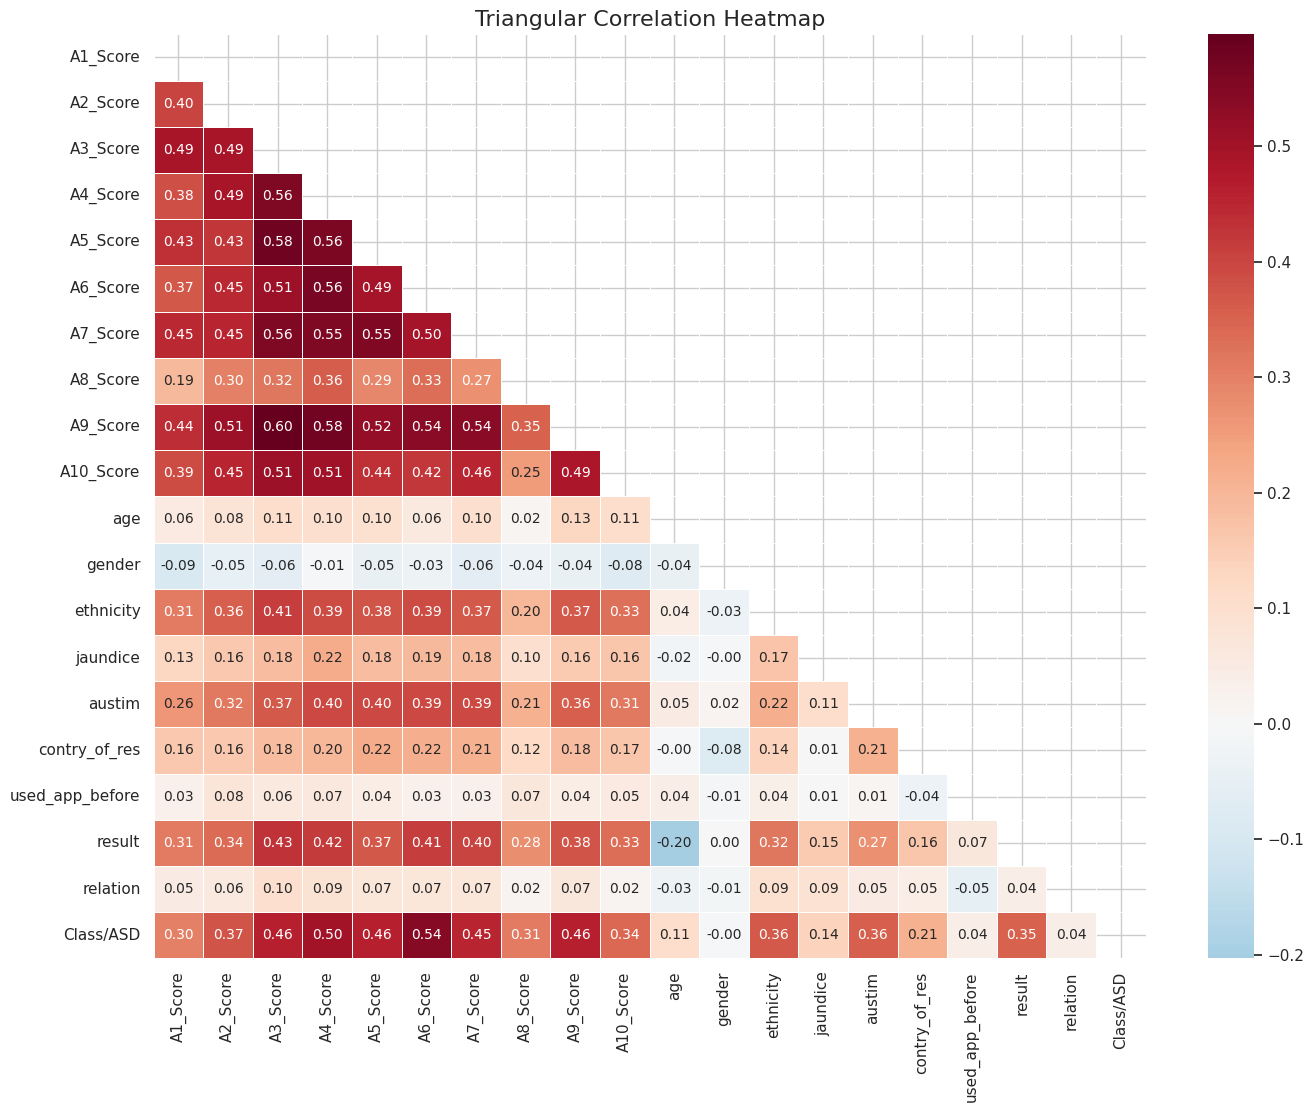

In [69]:
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title('Triangular Correlation Heatmap', fontsize=16)
plt.show()

## Key Insights from Exploratory Data Analysis (EDA)

1. **Outlier Detection**
   - A small number of outliers were identified in the **`age`** and **`result`** numerical features.
   - These observations may influence model performance and were considered during preprocessing.

2. **Target Variable Imbalance**
   - The target variable exhibits a noticeable **class imbalance**, indicating an unequal distribution of classes.
   - This may require imbalance-handling techniques during model training.

3. **Categorical Feature Imbalance**
   - Several categorical features show uneven category distributions.
   - Such imbalances can affect model learning and feature representation.

4. **Correlation Analysis**
   - No highly correlated features were found in the dataset.
   - This suggests a low risk of multicollinearity among the input variables.

5. **Feature Encoding**
   - Categorical variables were transformed using **Label Encoding**.
   - The fitted encoders were saved to ensure consistency during model deployment and inference.

In [70]:
def replace_outliers_with_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median = df[column].median()

    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), median, df[column])

    return df

for col in ['age', 'result']:
    df = replace_outliers_with_median(df, col)

print("Outliers replaced with median.")

Outliers replaced with median.


In [71]:
df = replace_outliers_with_median(df, "age")
df = replace_outliers_with_median(df, "result")

In [72]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1,0


**Train Test Split**

In [73]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [74]:
X = df.drop(columns=["Class/ASD"])
y = df["Class/ASD"]

In [75]:
print(X)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0           1         0         1         0         1         0         1   
1           0         0         0         0         0         0         0   
2           1         1         1         1         1         1         1   
3           0         0         0         0         0         0         0   
4           0         0         0         0         0         0         0   
..        ...       ...       ...       ...       ...       ...       ...   
795         0         1         0         0         0         0         0   
796         0         1         1         0         0         1         0   
797         0         0         0         0         0         0         0   
798         0         0         0         0         0         0         0   
799         0         1         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score   age  gender  ethnicity  jaundice  aust

In [76]:
print(y)

0      0
1      0
2      1
3      0
4      0
      ..
795    0
796    0
797    0
798    0
799    0
Name: Class/ASD, Length: 800, dtype: int64


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [79]:
y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [80]:
y_test.value_counts()

,count
Class/ASD,
0,124
1,36


**SMOTE (Synthetic Minority Oversampling technique)**

In [81]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [82]:
print(y_train_smote.shape)

(1030,)


In [83]:
print(y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


**Model Training**

In [84]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

Model           | Accuracy   | F1-Score   | Std Dev   
-------------------------------------------------------
Decision Tree   | 0.8330     | 0.8313     | 0.0235    
Random Forest   | 0.9126     | 0.9179     | 0.0075    
XGBoost         | 0.9019     | 0.9058     | 0.0128    


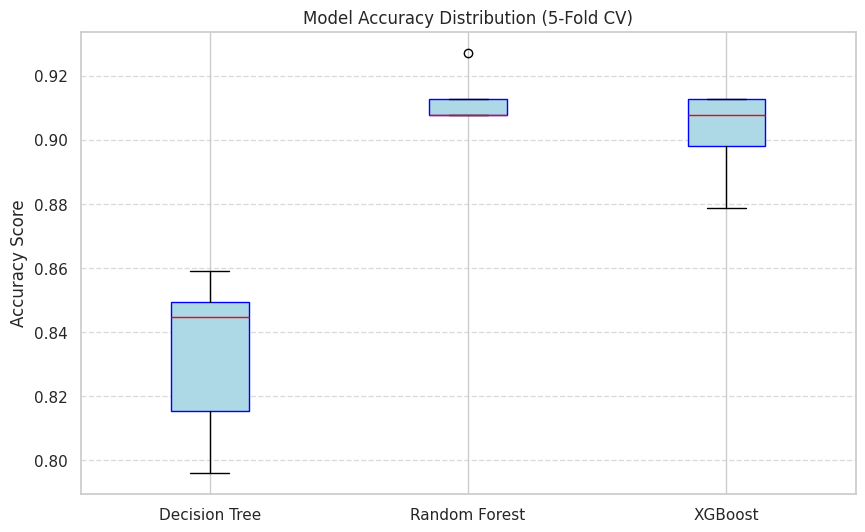

In [86]:
from sklearn.model_selection import cross_validate

results = {}
metrics = ['accuracy', 'precision', 'recall', 'f1']

print(f"{'Model':<15} | {'Accuracy':<10} | {'F1-Score':<10} | {'Std Dev':<10}")
print("-" * 55)

for model_name, model in models.items():
    cv_results = cross_validate(
        model, X_train_smote, y_train_smote,
        cv=5,
        scoring=metrics,
        return_train_score=False
    )

    results[model_name] = cv_results

    mean_acc = np.mean(cv_results['test_accuracy'])
    mean_f1 = np.mean(cv_results['test_f1'])
    std_acc = np.std(cv_results['test_accuracy'])

    print(f"{model_name:<15} | {mean_acc:<10.4f} | {mean_f1:<10.4f} | {std_acc:<10.4f}")

plt.figure(figsize=(10, 6))
model_names = list(results.keys())
boxplot_data = [results[name]['test_accuracy'] for name in model_names]

# Updated 'labels' to 'tick_labels' to address the DeprecationWarning
plt.boxplot(boxplot_data, tick_labels=model_names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'))
plt.title('Model Accuracy Distribution (5-Fold CV)')
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Final Model: Random Forest
------------------------------
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       124
           1       0.59      0.67      0.62        36

    accuracy                           0.82       160
   macro avg       0.74      0.76      0.75       160
weighted avg       0.83      0.82      0.82       160



<Figure size 800x600 with 0 Axes>

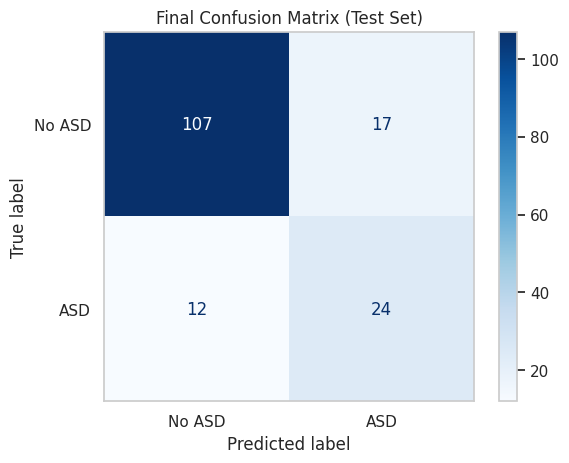

In [87]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Selecting the best model based on CV results
best_model = models['Random Forest']

# Fitting on the full SMOTE-augmented training set
best_model.fit(X_train_smote, y_train_smote)

# Making predictions on the original test set
y_pred = best_model.predict(X_test)

# Final Evaluation
print("Final Model: Random Forest")
print("-" * 30)
print(classification_report(y_test, y_pred))

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No ASD', 'ASD'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Final Confusion Matrix (Test Set)')
plt.grid(False)
plt.show()

**Model Selection & Hyperparameter Tuning**

In [90]:
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
xgboost_classifier = XGBClassifier(random_state=42)

In [91]:
# Hyperparameter grids for RandomizedSearchCV

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50, 70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


param_grid_rf = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}


param_grid_xgb = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.5, 0.7, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0]
}

In [92]:
random_search_dt = RandomizedSearchCV(estimator=decision_tree, param_distributions=param_grid_dt, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_rf = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid_rf, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgboost_classifier, param_distributions=param_grid_xgb, n_iter=20, cv=5, scoring="accuracy", random_state=42)

In [93]:
random_search_dt.fit(X_train_smote, y_train_smote)
random_search_rf.fit(X_train_smote, y_train_smote)
random_search_xgb.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [95]:
searches = [random_search_dt, random_search_rf, random_search_xgb]

# Find the search object with the highest best_score_
best_search = max(searches, key=lambda x: x.best_score_)

best_model = best_search.best_estimator_
best_score = best_search.best_score_

print(f"Best Model: {best_model}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")
print(f"Best Params: {best_search.best_params_}")

Best Model: RandomForestClassifier(bootstrap=False, max_depth=20, n_estimators=50,
                       random_state=42)
Best Cross-Validation Accuracy: 0.9214
Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}


Evaluation of Tuned Random Forest Model
----------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       124
           1       0.59      0.64      0.61        36

    accuracy                           0.82       160
   macro avg       0.74      0.75      0.75       160
weighted avg       0.82      0.82      0.82       160



<Figure size 800x600 with 0 Axes>

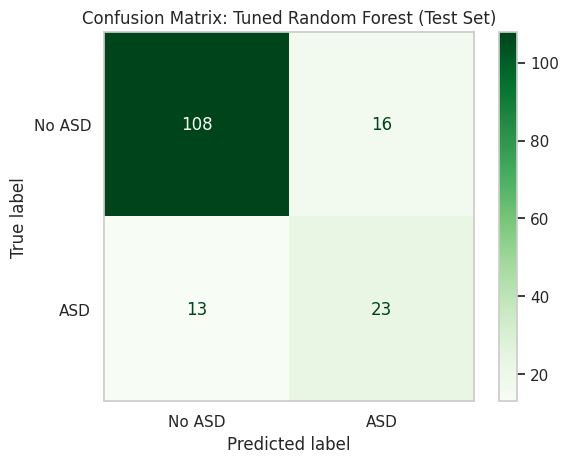

In [96]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Best model already extracted from the search results
y_pred_tuned = best_model.predict(X_test)

print("Evaluation of Tuned Random Forest Model")
print("-" * 40)
print(classification_report(y_test, y_pred_tuned))

# Plotting Confusion Matrix for the tuned model
plt.figure(figsize=(8, 6))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No ASD', 'ASD'])
disp.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix: Tuned Random Forest (Test Set)')
plt.grid(False)
plt.show()

### **Results Summary:**

*  **Test Accuracy:** 82%, which is consistent with our initial baseline, indicating the model is stable.
*  **Minority Class (ASD):** We achieved a recall of 64% and an F1-score of 0.61. This means the model is catching nearly two-thirds of the ASD cases in the test set.
*  **Precision/Recall Balance:** The precision for the ASD class is 59%, meaning when the model predicts ASD, it's correct about 6 out of 10 times.

In [97]:
with open("best_model.pkl", "wb") as f:
  pickle.dump(best_model, f)